<img src="starting_point.jpg" width="800">

Notebook for using the Surrounding self-energies for later use in the project.
Based on [Alan's notebook](../../resources/SE_Graphene_Example-TB.ipynb)

In [1]:
import matplotlib.pyplot as plt
import seaborn as sea
import numpy as np
import sisl
from sisl import Hamiltonian
import ase
from ase.visualize import view
from tqdm.auto import tqdm
# from SE_utils import loop_GF

# Create basis for pristine graphene layer (primitive unit cell)

In [2]:
bond = 1.43
gr = sisl.geom.graphene(bond, "C")
gr.plot(axes="xy")

# Make hamiltonian

In [3]:
Ham0 = Hamiltonian(gr)
print(Ham0)

Hamiltonian{non-zero: 0, orthogonal: True,
 Spin{unpolarized},
 Geometry{na: 2, no: 2,
  Atoms{species: 1,
   Atom{C, Z: 6, mass(au): 12.01070, maxR: -1.00000,
    Orbital{R: -1.00000, q0: 0.0}
   }: 2,
  },
  maxR: -1.00000,
  Lattice{nsc: [3 3 1],
   origin=[0.0000, 0.0000, 0.0000],
   A=[2.1450, -1.2384, 0.0000],
   B=[2.1450, 1.2384, 0.0000],
   C=[0.0000, 0.0000, 20.0000],
   bc=[Periodic,
       Periodic,
       Unknown]
  }
 }
}


# Define TB

In [4]:
bond = 1.43
r = (0.1*bond, bond + 0.01)
t = (0, -2.7)
Ham0.construct([r, t])
print(Ham0.Hk(format="array"))

[[ 0.  -8.1]
 [-8.1  0. ]]


warn:0: SislWarning:

Geometry.close_sc has been passed an 'atoms' argument together with an R value larger than the orbital ranges. If used together with 'sparse-matrix.construct' this can result in wrong couplings.



In [5]:
Ham = Ham0.tile(1,0).tile(1,1)

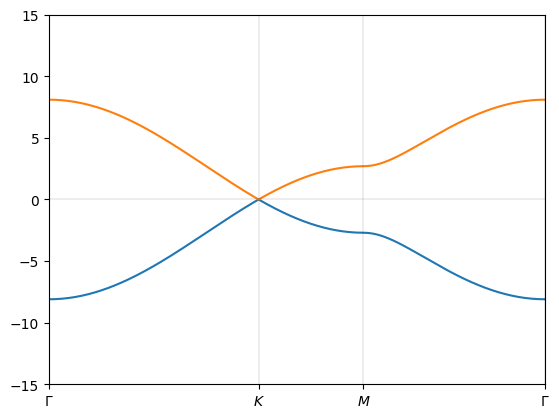

In [6]:
band = sisl.BandStructure(Ham, points= [[0., 0., 0.], [1 / 3, 2 / 3, 0], [0, 0.5, 0],[0., 0., 0.]],divisions= 300, names=[r'$\Gamma$', r"$K$", r"$M$",r'$\Gamma$'])
lineark, kticks, klabels = band.lineark(True)

fig, ax = plt.subplots()

bs = np.empty(shape=(len(band),2))
for ik, eigh in enumerate(band.apply.eigh()):
    bs[ik] = eigh

ax.plot(lineark, bs, label="TB")
for tick in kticks:
    ax.axvline(x=tick, lw=0.1, color="k")
ax.set(xlim=(kticks[0], kticks[-1]), ylim=(-15, 15))
ax.axhline(y=0, color="k", lw=0.1)
ax.set_xticks(kticks)
ax.set_xticklabels(klabels)

None

# sisl calculations

In [7]:
print(Ham0)

Hamiltonian{non-zero: 8, orthogonal: True,
 Spin{unpolarized},
 Geometry{na: 2, no: 2,
  Atoms{species: 1,
   Atom{C, Z: 6, mass(au): 12.01070, maxR: -1.00000,
    Orbital{R: -1.00000, q0: 0.0}
   }: 2,
  },
  maxR: -1.00000,
  Lattice{nsc: [3 3 1],
   origin=[0.0000, 0.0000, 0.0000],
   A=[2.1450, -1.2384, 0.0000],
   B=[2.1450, 1.2384, 0.0000],
   C=[0.0000, 0.0000, 20.0000],
   bc=[Periodic,
       Periodic,
       Unknown]
  }
 }
}


In [8]:
eta = 0.001* 1j
dE=0.1
Emax = 3.0
Emin = -Emax
energies = np.arange(Emin, Emax + dE, dE)

# Real Space Self Energies
N0 = 12
N1 = 12
nk1 = int(np.ceil(3*900/N1))

rse = sisl.RealSpaceSE(Ham, 0, 1, (N0, N1, 1))
rse.setup(eta= 0.001, bz=sisl.MonkhorstPack(Ham0, [1, nk1, 1]))
HamNN = Ham0.tile(N0, 0).tile(N1, 1)
geomNN = HamNN.geometry
elec_indices = rse.real_space_coupling(geomNN)[1]
nC = len(elec_indices)   # number of coupling atoms
HamNN.set_nsc([1,1,1]) # remove al pbc

# indexes sort
all_atoms=np.arange(0,HamNN.na)
inside_atoms = np.delete(all_atoms, elec_indices, axis=None)
alist = np.concatenate([elec_indices, inside_atoms])

# Reordering Hamiltonain
HamNN_reorder=HamNN.sub(alist)
HamNN_reorder.reduce()
HamNN_reorder.set_nsc([1,1,1]) # remove al pbc
H_sub = HamNN_reorder.Hk(format="array")   
S_sub = HamNN_reorder.Sk(format="array")

In [9]:
def calc_GF(E,eta,rse,H_sub,S_sub,alist=None):
    z = E +  eta
    A = z*S_sub - H_sub 
    RSE = rse.self_energy(z)
    if alist is not None:
        RSE = RSE[np.ix_(alist, alist)]
        A[0:len(alist),0:len(alist)] -= RSE  
    else: 
        A -= RSE
    G = np.linalg.inv(A)   
    ldos = - (1.0 / np.pi) * np.imag(np.diag(G@S_sub))
    # dos = - (1.0 / np.pi) * np.imag(np.trace(G@S_sub)) 
    return ldos


def loop_GF(energies,eta,rse,H_sub,S_sub,alist=None):
    # Observables
    N = H_sub.shape[0]
    # DOS = np.zeros_like(energies, dtype=float)
    LDOS = np.zeros((N, len(energies)), dtype=float)  

    # Loop
    for iE, E in enumerate(tqdm(energies, desc='DOS')):
        ldos = calc_GF(E,eta,rse,H_sub,S_sub,alist=alist)
        # DOS[iE] = np.sum(ldos)
        LDOS[:,iE] = ldos
    return LDOS

In [10]:
import time
t0 = time.perf_counter()
LDOS = loop_GF(energies,eta,rse,H_sub,S_sub,alist=alist)
t1 = time.perf_counter()
print(f"Total runtime: {t1 - t0:.2f} seconds")
print(f"Time per energy: {(t1 - t0)/len(energies):.4f} s")
LDOS_dev_OG = LDOS[nC:,:]
DOS_dev_OG = LDOS_dev_OG.sum(axis=0)

DOS:   0%|          | 0/61 [00:00<?, ?it/s]

Total runtime: 66.02 seconds
Time per energy: 1.0824 s


In [98]:
def reorder(parent):
    if not isinstance(parent, sisl.RealSpaceSE):
        raise TypeError("`parent`must be of type `sisl.RealsapceSE`.")
    H = parent.real_space_parent()
    _, elec_indices = parent.real_space_coupling(True)
    
    all_atoms = np.arange(0, H.na)
    inside_atoms = np.delete(arr=all_atoms, # parent array to remove indices from
                             obj=elec_indices, # indices to remove 
                             axis=0 # if None will flatten `arr` before removal
                            )
    atoms_list = np.concatenate([elec_indices, inside_atoms])
    H_reorder = H.sub(atoms_list)
    H_reorder.reduce()
    H_reorder.set_nsc([1,1,1])
    return H_reorder, atoms_list

def sHam(parent, tile, nk1, eta):
    """Method for calculating the surrounding (real-space) self-energy Hamiltonian for a tiled parent structure.

    Parameters
    ----------
    Parent : sisl.Geometry
        a physical object from which to calculate the real-space self-energy.
        The parent object *must* have only 3 supercells along the direction where
        self-energies are used.
    tile : tuple, int
        How many times to tile in semi-inf and transverse direction. If an integer is used, will use this value for both.
    nk1 : int
        Number of samples in k-space along transverse direction 
    eta : float or complex
        perturbation used for self-energy calculations

    Returns
    -------
    H_reorder : sisl.Hamiltonian
        Hamiltonian reordered to have the electrode as the first `nC` elements
    rse : sisl.RealSpaceSE
        The Real-space self-energy object used for calculations
    nC : int
        Number of atoms in electrode.
    """
    if not isinstance(eta, complex):
        eta = eta*1j # ensure the format is a complex number
    if isinstance(tile, tuple): # extract the tiling along semi-infinite and transverse direction
        Na = tile[0]
        Nb = tile[1]
    elif isinstance(tile, int):
        Na = Nb = tile
    
    # define the Realspace SE based on primitive unit-cell Hamiltonian tiled by Na x Nb
    rse = sisl.RealSpaceSE(parent=parent, # Hamiltonian the method inherets
                           semi_axis=0, # semi-infinite direction (in unit-cell directions A, B, C)
                           k_axes=1, # k-sampling direction (transverse to semi-inf)
                           unfold=(Na, Nb, 1) # how to tile/unfold the inhereted structure in A, B, C directions
                           ) 
    rse.setup(eta=np.imag(eta), bz=sisl.MonkhorstPack(parent=parent, nkpt=[1, nk1, 1])) # setup the Realspace Self-energy to use eta and `nk1`-points in around gamma point in the transverse direction.
    
    H_reorder, alist = reorder(rse)
    return H_reorder, rse, alist


from scipy import linalg as lin
from scipy import sparse as spa
from scipy.sparse import linalg as spla
from numba import njit

# @njit
def _infer_solver(M):
    if spa.isspmatrix(M):
        lu = spla.splu(M)
        solver = lambda e: lu.solve(e)
    else:
        lu, piv = lin.lu_factor(M)
        solver = lambda e: lin.lu_solve((lu, piv), e)
    return solver

# @njit
def _diag_of_inv(M):
    # return np.diag(lin.inv(M))
    K = len(M)
    diag = np.zeros(K, dtype=complex)
    
    solver = _infer_solver(M)
    for i, idx in enumerate(tqdm(np.arange(K), desc="Sparse diagonal solves", leave=False)):
        ei = np.zeros(K)
        ei[idx] = 1.0
        xi = solver(ei)
        diag[i] = xi[idx]
    return diag

# @njit
def _calc_invG(z, RSE, H_sub, S_sub, alist):
#     print(f"""
# {  RSE.shape = }
# {H_sub.shape = }
# {S_sub.shape = }
#           """)
    invG = S_sub*z - H_sub
    invG[0:len(alist), 0:len(alist)] -= RSE
    return invG

# @njit
def _ldos(G):
    if (G.ndim == 1): diagG = G
    elif (G.ndim == 2): diagG = np.diag(G)
    else: raise ValueError(f"The input to {_ldos.__name__} must be either GF or its diagonal;\n{ G.ndim = }\n {G.shape = }")
    return -(1/np.pi)*np.imag(diagG)

# @njit
def _reorder_rse(RSE, alist):
    return RSE[np.ix_(alist, alist)]


def _loop_ldos(z, H_reordered, RSE_reordered, alist):
    H = H_reordered.Hk(format="array")
    S = H_reordered.Sk(format="array")
    invG = _calc_invG(z, RSE_reordered, H_sub, S_sub, alist)
    diagG = _diag_of_inv(invG)
    return _ldos(diagG)

def _calc_ldos(energies, rse):
    HamNN_reorder, alist = reorder(rse)
    eta = rse._options["eta"]
    if isinstance(eta, complex):
        eta = np.imag(eta)
    elif isinstance(eta, float):
        pass
    else:
        raise ValueError(f"the eta used for RSE is invalid ({type(eta) = }; {eta = })")
    
    N = len(HamNN)
    print(f"{alist = }")
    LDOS = np.zeros((len(energies), N), dtype=float)
    for iE, E in enumerate(tqdm(energies, desc="LDOS", leave=True)):
        z = E + eta*1j
        RSE = rse.self_energy(z)
        RSE_reorder = _reorder_rse(RSE, alist)
        LDOS[iE, :] = _loop_ldos(z, HamNN_reorder, RSE_reorder, alist)
    
    return LDOS

@njit
def _calc_dos(ldos):
    return np.sum(ldos, axis=1)

In [99]:
Na = Nb = 12
eta = 1e-2
nk_func = lambda n: int(np.ceil(100/n))
H, rse, nC = sHam(parent=Ham0, nk1=nk_func(Nb), tile=Na, eta=eta)


In [100]:
LDOS_dev_new = _calc_ldos(energies, rse)
DOS_dev_new = _calc_dos(LDOS_dev_new)

alist = array([  0,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  23,
        24,  47,  48,  71,  72,  95,  96, 119, 120, 143, 144, 167, 168,
       191, 192, 215, 216, 239, 240, 263, 264, 265, 267, 269, 271, 273,
       275, 277, 279, 281, 283, 285, 287,   1,   3,   5,   7,   9,  11,
        13,  15,  17,  19,  21,  25,  26,  27,  28,  29,  30,  31,  32,
        33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,
        46,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,
        61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  73,  74,  75,
        76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,
        89,  90,  91,  92,  93,  94,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 145, 146,
       147, 148, 149, 150, 151, 152, 153, 154, 155, 156,

LDOS:   0%|          | 0/61 [00:00<?, ?it/s]

Sparse diagonal solves:   0%|          | 0/288 [00:00<?, ?it/s]

Sparse diagonal solves:   0%|          | 0/288 [00:00<?, ?it/s]

Sparse diagonal solves:   0%|          | 0/288 [00:00<?, ?it/s]

...

Sparse diagonal solves:   0%|          | 0/288 [00:00<?, ?it/s]

Sparse diagonal solves:   0%|          | 0/288 [00:00<?, ?it/s]

Sparse diagonal solves:   0%|          | 0/288 [00:00<?, ?it/s]

Sparse diagonal solves:   0%|          | 0/288 [00:00<?, ?it/s]

Sparse diagonal solves:   0%|          | 0/288 [00:00<?, ?it/s]

In [101]:
# from warnings import warn

# def _calc_GF(z, rse, A):
#     # H = rse.real_space_parent()
#     # H_sub = H.Hk(format="array", dtype=float)
#     # S_sub = H.Sk(format="array", dtype=float)
    
#     # z = E + eta
#     # A = z*S_sub - H_sub 
#     # RSE = calc_RSE(E, eta, rse, alist=alist)
#     RSE = rse.self_energy(z, dtype=np.complex128)
#     A -= RSE
#     G = np.linalg.inv(A)   
#     ldos = - (1.0 / np.pi) * np.imag(np.diag(G@S_sub))
#     return ldos


# def _loop_GF(energies,rse, alist= None):
#     warn("testing using `rse.real_space_parent()` method for convenience")
#     # Observables
#     H = rse.real_space_parent()
#     N = len(H)
#     eta = rse._options["eta"]
#     if not isinstance(eta, complex):
#         eta = eta*1j
    
#     # DOS = np.zeros_like(energies, dtype=float)
#     LDOS = np.zeros((N, len(energies)), dtype=float)  
#     H_sub = H.Hk(format="array")
#     S_sub = H.Sk(format="array")
    
#     # Loop
#     for iE, E in enumerate(tqdm(energies, desc='DOS')):
#         z = (E + eta)
#         A = z*S_sub - H_sub
#         ldos = _calc_GF(z, rse, A)
#         # DOS[iE] = np.sum(ldos)
#         LDOS[:,iE] = ldos
#     return LDOS

# eta = rse._options["eta"]

# LDOS_dev_new = loop_GF(energies,eta, rse, H_sub, S_sub)
# DOS_dev_new = LDOS_dev_new.sum(axis=0)


/tmp/ipykernel_90899/3259784192.py:16: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



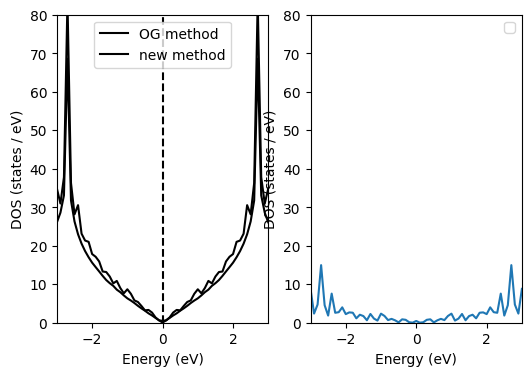

In [103]:
# === plot DOS ===
E_idx=31
E_idx=min(E_idx, len(energies)) -1

fig, ax = plt.subplots(1, 2, figsize=(6,4))

ax[0].plot(energies, DOS_dev_OG, c="k", label="OG method")
ax[0].plot(energies, DOS_dev_new, c="k", label="new method")
ax[0].vlines(x=energies[E_idx],ymin=0,ymax=600,color='k',linestyle='dashed')


for a in ax:
    a.set_xlabel("Energy (eV)")
    a.set_ylabel("DOS (states / eV)")
    a.set(ylim=(0,80), xlim=(-3,3))
    a.legend()

ax[1].plot(energies, np.abs(DOS_dev_new - DOS_dev_OG), label="Diff")
ax
None

# Tile the primitive unit cell hamiltonian

In [ ]:
# geomNN.plot(axes="xy")

# Remove from the device if part of the electrode

In [ ]:
# Ham_elec = HamNN.sub(elec_indices)
# Ham_inside = HamNN.sub(inside_atoms)
# Ham_inside.geometry.plot(axes="xy")

In [ ]:
# from sisl.viz import merge_plots
# plots = [
#     Ham_inside.geometry.plot(axes="xy", atoms_style={"color":"gray"}), # the device atoms
#     Ham_elec.geometry.plot(axes="xy", atoms_style=({"color":"red"}))
# ]
# merge_plots( *plots, composite_method="multiple"
# )

# View atoms to show atom index labels before reordering

In [ ]:
# view(HamNN.geometry.to.ase())
# view(Ham_inside.geometry.to.ase())

# View the reordered atoms

In [ ]:
# view(HamNN_reorder.geometry.to.ase())